<a href="https://colab.research.google.com/github/antraraj441/OIBSIP/blob/main/AntraRaj_2_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# 2. Load dataset
df = pd.read_excel("Online Retail.xlsx")

# Inspect data
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------      

In [3]:
# 3. Clean data

# Remove rows without CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled transactions
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove invalid quantity and price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Create total purchase amount
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(df.shape)

(397884, 9)


4. Descriptive statistics


In [4]:
print("Average Purchase Value:",
      df['TotalPrice'].mean())

print("Purchase Frequency:",
      df['InvoiceNo'].nunique())

print("Total Customer Lifetime Value:",
      df.groupby('CustomerID')['TotalPrice'].sum().mean())

Average Purchase Value: 22.396999889415003
Purchase Frequency: 18532
Total Customer Lifetime Value: 2054.2664601198708


5. Create RFM features

In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.head())
print(rfm.describe())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


6. Standardisation

In [7]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

7. Elbow Method

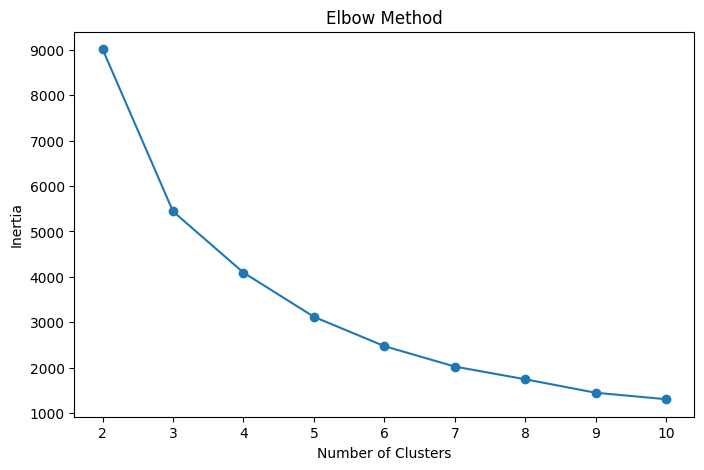

In [8]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

8. Apply K-Means

In [9]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        3
12347.0           2          7   4310.00        0
12348.0          75          4   1797.24        0
12349.0          19          1   1757.55        0
12350.0         310          1    334.40        1


9. Cluster visualisation

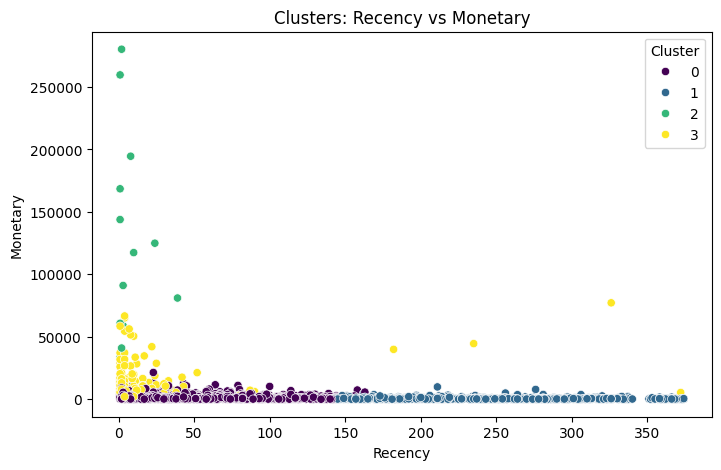

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis'
)

plt.title("Clusters: Recency vs Monetary")
plt.show()

Second combination

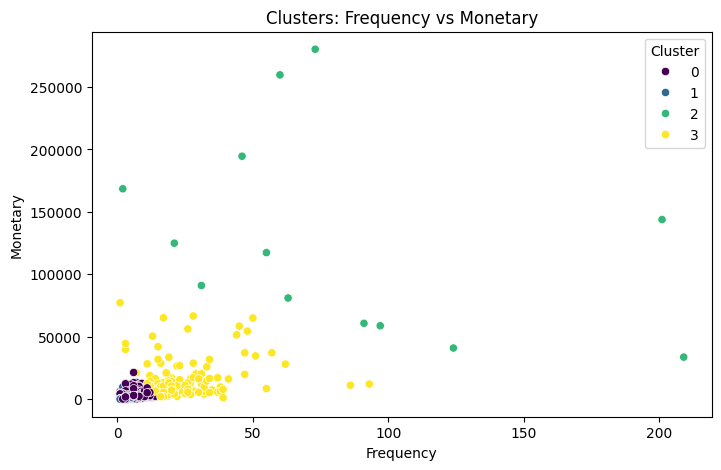

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis'
)

plt.title("Clusters: Frequency vs Monetary")
plt.show()

10. Cluster profiling

In [12]:
cluster_profile = rfm.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

print(cluster_profile)

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1359.049284
1        248.075914   1.552015     480.617480
2          7.384615  82.538462  127338.313846
3         15.500000  22.333333   12709.090490


Customer count

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


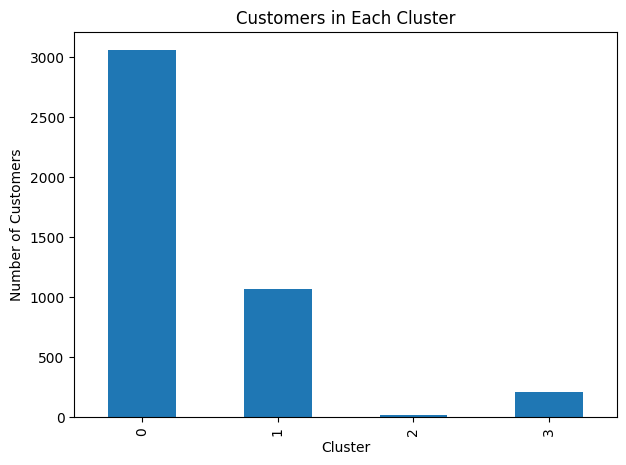

In [13]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

print(cluster_counts)

cluster_counts.plot(
    kind='bar',
    figsize=(7,5)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customers in Each Cluster")
plt.show()

Marketing recommendations


Marketing Recommendations
Cluster 0 – Regular Customers
Moderate spending and purchase frequency.
Use personalized discounts and product recommendations.
Encourage them to purchase more frequently.
Cluster 1 – Inactive Customers
Very high recency means they have not purchased for a long time.
Low frequency and spending.
Send re-engagement emails, special discounts, and limited-time offers.
Cluster 2 – VIP Customers
Very recent purchases, extremely high frequency and highest spending.
Provide loyalty rewards, exclusive offers, early access to products, and premium customer service.
Focus on retention rather than heavy discounts.
Cluster 3 – Loyal Customers
Recent purchases with high frequency and spending.
Use loyalty programs, cross-selling, bundles, and personalized recommendations.
Encourage them to become even higher-value customers.
